In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

In [2]:
# Select any 4 datasets for training
csv_files = [
    '../data/Monday-WorkingHours.pcap_ISCX.csv',
    '../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    '../data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    '../data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
]

# Load and combine
data_list = [pd.read_csv(file) for file in csv_files]
data = pd.concat(data_list, ignore_index=True)

# Clean column names
data.columns = data.columns.str.strip()

# Encode labels
data['Label'] = data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Check data balance
print(data['Label'].value_counts())
print("\n Data Loaded Successfully!")

Label
0    1043739
1     286993
Name: count, dtype: int64

 Data Loaded Successfully!


In [3]:
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [4]:
# Features and target
X = data.drop('Label', axis=1)
y = data['Label']

# Replace infinities and NaNs
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Data preprocessing complete!")

Data preprocessing complete!


In [5]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=None, 
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest training complete!")

Random Forest training complete!


In [6]:
# Predict
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.6f}")

Accuracy: 0.998674


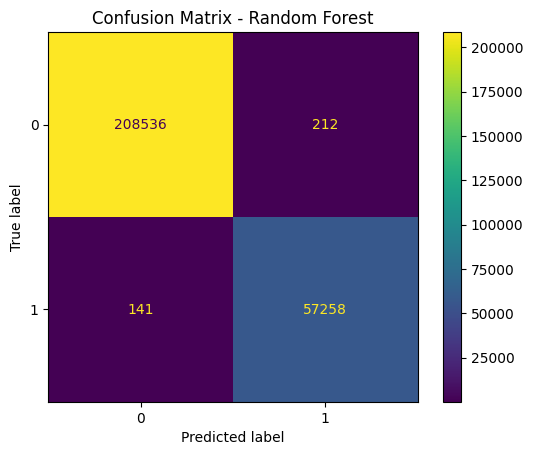

In [7]:
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()

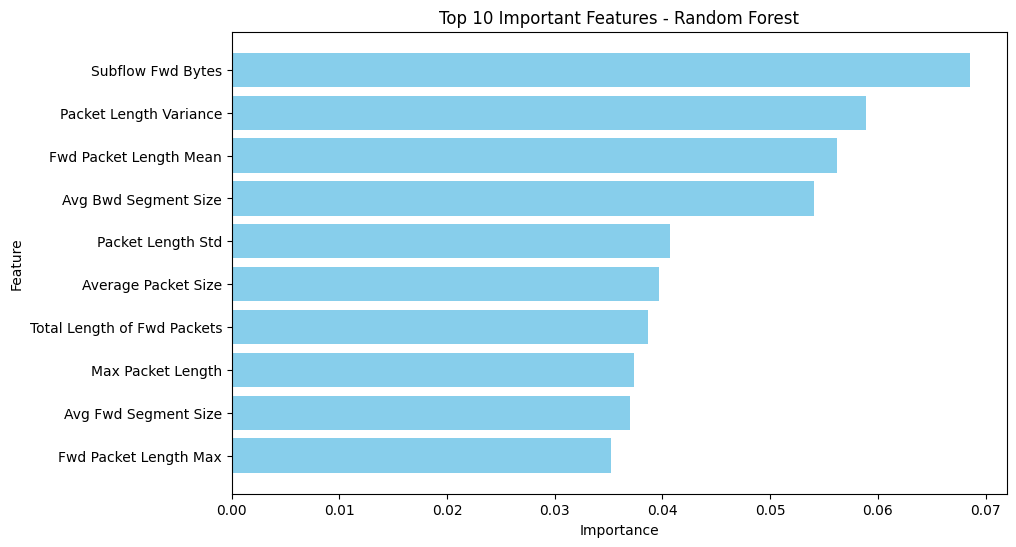

In [8]:
# Top 10 important features
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top10 = feat_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features - Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [11]:
joblib.dump(rf_model, './models/random_forest.pkl')
print("Random Forest model saved to '../models/random_forest.pkl'")

Random Forest model saved to '../models/random_forest.pkl'
